# MultiHopBench deterministic scorer

This notebook takes:

1. the canonical `multihop_dataset_raw.jsonl`;
2. a JSONL file containing judge results in the following outer container:

```json
{
  "id": "books_l3_0023",
  "model_name": "gpt-5-mini-search",
  "judge_answer": "{...}",
  "llm_as_a_judge_prompt": "...",
  "reasoning_judge_answer": {}
}
```

`judge_answer` may be either a JSON string or an already parsed object. The `llm_as_a_judge_prompt` and `reasoning_judge_answer` fields are retained for auditing but do not participate in scoring.

The notebook performs strict schema validation, cross-checks each annotation against the corresponding dataset record, computes atomic metrics, eight answerable-score groups or separate zero-gold groups, a score for each record, and a macro-average for each model. Invalid annotations are not assigned an automatic zero; they are written to `validation_errors.jsonl`.

**Important:** the legacy judge v1 format with precomputed fields is not compatible with this scorer. `judge_answer` must contain the new atomic annotation.


## Scoring specification — calibrated v3

Version v3 retains all v2 rules and adds one narrowly targeted calibration component for the `possibly_correct_not_in_gold` status.

- `soft_non_gold_weight` remains equal to `0.5`;
- plausible non-gold candidates receive a small amount of additional credit only in proportion to their share among extracted entities and the degree to which their constraints are supported;
- the bonus does not apply to `constraint_violation`, `wrong_domain`, `unsupported_entity`, or `nonexistent_hallucination`;
- all other v2 weights, penalties, and caps remain unchanged.


## 1. Environment and dependencies

Install the schema-validation dependency and import the libraries used throughout the pipeline.


In [1]:
%pip install "jsonschema>=4.18,<5"


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard-library, numerical, validation, and notebook-display dependencies.
from __future__ import annotations

from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Iterable
import hashlib
import json
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from jsonschema import Draft202012Validator
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 120)


## 2. Run configuration

Resolve repository paths, define run defaults, and centralize all scoring constants.


In [3]:
# === EDIT THESE PATHS FOR A REAL RUN ===
from pathlib import Path

# Repository root detection: works with both cwd=project and cwd=project/src
CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        f"Could not determine the project root from {CURRENT_DIR}"
    )

DATASET_PATH = PROJECT_ROOT / "data" / "multihop_dataset_raw.jsonl"
JUDGE_RESULTS_PATH = PROJECT_ROOT / "data" / "judge_results.jsonl"
SCHEMA_PATH = PROJECT_ROOT / "prompts" / "judge_atomic.schema.json"
OUTPUT_DIR = PROJECT_ROOT / "data" / "scoring_outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEFAULT_RUN_ID = "default"
DEFAULT_SETTING = "default"
DEFAULT_LANGUAGE = "ru"

OFFICIAL_REQUIRES_FULL_DATASET = True
OFFICIAL_REQUIRES_NO_INVALID_ROWS = True
OFFICIAL_REQUIRES_NO_REVIEW_ROWS = True

for name, path in {
    "Dataset": DATASET_PATH,
    "Judge results": JUDGE_RESULTS_PATH,
    "Schema": SCHEMA_PATH,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"{name} not found: {path}")

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET_PATH)
print("Judge results:", JUDGE_RESULTS_PATH)
print("Schema:", SCHEMA_PATH)
print("Outputs:", OUTPUT_DIR)


Project root: /Users/matvey/Desktop/multihop_benchmark
Dataset: /Users/matvey/Desktop/multihop_benchmark/data/multihop_dataset_raw.jsonl
Judge results: /Users/matvey/Desktop/multihop_benchmark/data/calibration_judge_results_16.jsonl
Schema: /Users/matvey/Desktop/multihop_benchmark/prompts/judge_atomic.schema.json
Outputs: /Users/matvey/Desktop/multihop_benchmark/data/scoring_outputs_calibration_1


In [4]:
# Keep all scoring and calibration constants in one immutable configuration object.
@dataclass(frozen=True)
class ScoringConfig:
    soft_non_gold_weight: float = 0.5
    unknown_constraint_credit: float = 0.5
    severity_critical: float = 1.0
    severity_important: float = 0.6
    severity_standard: float = 0.3

    format_clean: float = 1.0
    format_minor_issues: float = 0.7
    format_hard_to_parse: float = 0.4
    format_unparseable: float = 0.0

    explanation_adequate: float = 1.0
    explanation_partial: float = 0.5
    explanation_incorrect: float = 0.0
    explanation_absent: float = 0.0

    # Calibration v3.
    clean_underanswer_penalty_weight: float = 0.31
    possible_non_gold_support_weight: float = 0.11
    all_wrong_domain_score_cap: float = 10.0
    all_nonexistent_score_cap: float = 5.0
    zero_gold_entities_score_cap: float = 3.0

    round_digits: int = 6

SCORING_CONFIG = ScoringConfig()

VALID_STATUSES = {"gold_match", "gold_alias_match", "correct_by_constraints"}
POSSIBLE_STATUS = "possibly_correct_not_in_gold"
CONSTRAINT_VIOLATION_STATUS = "constraint_violation"
WRONG_DOMAIN_STATUS = "wrong_domain"
SUBSTITUTION_STATUS = "entity_substitution"
UNSUPPORTED_STATUS = "unsupported_entity"
NONEXISTENT_STATUS = "nonexistent_hallucination"
AMBIGUOUS_STATUS = "ambiguous"
GOLD_STATUSES = {"gold_match", "gold_alias_match"}

SEVERITY_WEIGHTS = {
    "critical": SCORING_CONFIG.severity_critical,
    "important": SCORING_CONFIG.severity_important,
    "standard": SCORING_CONFIG.severity_standard,
}
FORMAT_VALUES = {
    "clean": SCORING_CONFIG.format_clean,
    "minor_issues": SCORING_CONFIG.format_minor_issues,
    "hard_to_parse": SCORING_CONFIG.format_hard_to_parse,
    "unparseable": SCORING_CONFIG.format_unparseable,
}
EXPLANATION_VALUES = {
    "adequate": SCORING_CONFIG.explanation_adequate,
    "partial": SCORING_CONFIG.explanation_partial,
    "incorrect": SCORING_CONFIG.explanation_incorrect,
    "absent": SCORING_CONFIG.explanation_absent,
    "not_applicable": 0.0,
}

asdict(SCORING_CONFIG)


{'soft_non_gold_weight': 0.5,
 'unknown_constraint_credit': 0.5,
 'severity_critical': 1.0,
 'severity_important': 0.6,
 'severity_standard': 0.3,
 'format_clean': 1.0,
 'format_minor_issues': 0.7,
 'format_hard_to_parse': 0.4,
 'format_unparseable': 0.0,
 'explanation_adequate': 1.0,
 'explanation_partial': 0.5,
 'explanation_incorrect': 0.0,
 'explanation_absent': 0.0,
 'clean_underanswer_penalty_weight': 0.31,
 'possible_non_gold_support_weight': 0.11,
 'all_wrong_domain_score_cap': 10.0,
 'all_nonexistent_score_cap': 5.0,
 'zero_gold_entities_score_cap': 3.0,
 'round_digits': 6}

## 3. Shared utilities and dataset helpers

These helpers handle normalization, safe arithmetic, JSONL parsing, hashing, and metadata inferred from canonical dataset records.


In [5]:
# Generic helpers for normalization, hashing, parsing, and safe numerical operations.
def clip01(value: float | int | None) -> float | None:
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    return float(min(1.0, max(0.0, float(value))))


def safe_div(num: float, den: float, default: float = 0.0) -> float:
    return float(num / den) if den else float(default)


def normalize_text(value: Any) -> str:
    if value is None:
        return ""
    text = str(value).casefold().strip()
    text = re.sub(r"[\s ]+", " ", text)
    text = text.strip("\"'«»“”‘’`")
    return text.strip()


def file_sha256(path: Path) -> str | None:
    if not path.exists():
        return None
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            if not line.strip():
                continue
            try:
                row = json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSONL at {path}:{line_no}: {exc}") from exc
            if not isinstance(row, dict):
                raise ValueError(f"Expected object at {path}:{line_no}, got {type(row).__name__}")
            row["_line_no"] = line_no
            rows.append(row)
    return rows


def parse_judge_answer(value: Any) -> dict[str, Any]:
    if isinstance(value, dict):
        return value
    if not isinstance(value, str) or not value.strip():
        raise ValueError("judge_answer must be a non-empty JSON string or object")
    text = value.strip()
    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
        text = re.sub(r"\s*```$", "", text)
    parsed = json.loads(text)
    if not isinstance(parsed, dict):
        raise ValueError("judge_answer JSON must be an object")
    return parsed


In [6]:
# Dataset-derived helpers for answerability, subsets, gold completeness, and target size.
def infer_answerability(record: dict[str, Any]) -> str:
    meta = record.get("gold_collection_meta") or {}
    return "zero_gold" if bool(meta.get("is_zero_gold")) else "answerable"


def infer_subset(record: dict[str, Any]) -> str:
    if infer_answerability(record) == "zero_gold":
        return "zero_gold"
    if record.get("domain") in {"kqapro", "mintaka"}:
        return "external_complex"
    return "easy_control" if record.get("complexity") in {"L1", "L2"} else "hard_core"


def infer_gold_total(record: dict[str, Any]) -> int:
    meta = record.get("gold_collection_meta") or {}
    for key in ("gold_total_before_limit", "gold_returned_before_limits", "gold_returned"):
        value = meta.get(key)
        if isinstance(value, int) and value >= 0:
            return value
        if isinstance(value, str) and value.isdigit():
            return int(value)
    return max(
        len(record.get("gold_answer_qids") or []),
        len(record.get("gold_answer_labels_ru") or []),
        len(record.get("gold_answer_labels_en") or []),
    )


def infer_gold_completeness_warning(record: dict[str, Any]) -> bool:
    if infer_answerability(record) == "zero_gold":
        return False
    meta = record.get("gold_collection_meta") or {}
    incomplete_flags = (
        "gold_may_be_incomplete_due_to_wdqs_limit",
        "gold_truncated_by_local_limit",
        "gold_may_be_incomplete_due_to_cache_limit",
        "kind_cache_limit_hit",
    )
    if any(bool(meta.get(key)) for key in incomplete_flags):
        return True
    has_gold = bool(record.get("gold_answer_qids") or record.get("gold_answer_labels_ru") or record.get("gold_answer_labels_en"))
    return not has_gold


def infer_target_count(record: dict[str, Any]) -> int | None:
    value = record.get("requested_count")
    if isinstance(value, bool):
        return None
    if isinstance(value, (int, float)) and float(value).is_integer() and value > 0:
        return int(value)
    if isinstance(value, str):
        stripped = value.strip().lower()
        if stripped.isdigit() and int(stripped) > 0:
            return int(stripped)
        if stripped == "all" and not infer_gold_completeness_warning(record):
            total = infer_gold_total(record)
            return total if total > 0 else None
    return None


## 4. Input loading and annotation validation

Load the canonical dataset and judge outputs, initialize JSON Schema validation, and enforce dataset-specific consistency checks.


In [7]:
# Load canonical inputs and initialize the strict judge-output validator.
dataset_rows = read_jsonl(DATASET_PATH)
judge_rows = read_jsonl(JUDGE_RESULTS_PATH)

if not SCHEMA_PATH.exists():
    raise FileNotFoundError(f"Canonical judge schema not found: {SCHEMA_PATH}")
judge_schema = json.loads(SCHEMA_PATH.read_text(encoding="utf-8"))
schema_validator = Draft202012Validator(judge_schema)

# Dataset integrity.
dataset_ids = [row.get("id") for row in dataset_rows]
if len(dataset_ids) != len(set(dataset_ids)):
    raise ValueError("Duplicate ids found in canonical dataset")
dataset_by_id = {row["id"]: row for row in dataset_rows}

print(f"Dataset records: {len(dataset_rows):,}")
print(f"Judge-result rows: {len(judge_rows):,}")
print(f"Models: {len({str(r.get('model_name')) for r in judge_rows}):,}")


Dataset records: 1,300
Judge-result rows: 16
Models: 1


In [8]:
# Validate both the JSON schema and dataset-specific annotation invariants.
def schema_errors(annotation: dict[str, Any]) -> list[str]:
    errors = []
    for err in sorted(schema_validator.iter_errors(annotation), key=lambda e: list(e.path)):
        path = ".".join(map(str, err.path)) or "$"
        errors.append(f"schema:{path}: {err.message}")
    return errors


def cross_validate(
    outer: dict[str, Any],
    annotation: dict[str, Any],
    record: dict[str, Any],
) -> tuple[list[str], list[str]]:
    errors: list[str] = []
    warnings: list[str] = []

    outer_id = str(outer.get("id", ""))
    query_id = str(annotation.get("query_id", ""))
    if not outer_id:
        errors.append("outer id is empty")
    if query_id != outer_id:
        errors.append(f"query_id mismatch: outer={outer_id!r}, judge={query_id!r}")

    expected_answerability = infer_answerability(record)
    if annotation.get("answerability") != expected_answerability:
        errors.append(
            f"answerability mismatch: dataset={expected_answerability}, judge={annotation.get('answerability')}"
        )

    consistency = (annotation.get("input_consistency") or {}).get("status")
    if consistency != "consistent":
        warnings.append(f"input_consistency={consistency}")

    expected_constraint_keys = list((record.get("constraints") or {}).keys())
    expected_key_set = set(expected_constraint_keys)

    gold_qids = set(record.get("gold_answer_qids") or [])
    gold_labels = {
        normalize_text(x)
        for x in ((record.get("gold_answer_labels_ru") or []) + (record.get("gold_answer_labels_en") or []))
        if normalize_text(x)
    }

    normalized_entities: list[str] = []
    for idx, entity in enumerate(annotation.get("entities") or []):
        prefix = f"entities[{idx}]"
        normalized = normalize_text(entity.get("normalized_name"))
        if normalized:
            normalized_entities.append(normalized)

        checks = entity.get("constraint_checks") or []
        keys = [check.get("constraint_key") for check in checks]
        if len(keys) != len(set(keys)):
            errors.append(f"{prefix}: duplicate constraint_key values")
        if set(keys) != expected_key_set:
            missing = sorted(expected_key_set - set(keys))
            extra = sorted(set(keys) - expected_key_set)
            errors.append(f"{prefix}: constraint keys mismatch; missing={missing}, extra={extra}")

        status = entity.get("status")
        violated = [c for c in checks if c.get("status") == "violated"]
        unknown = [c for c in checks if c.get("status") == "unknown"]

        if status in VALID_STATUSES and violated:
            errors.append(f"{prefix}: valid status {status} contains violated constraints")
        if status == "correct_by_constraints" and (violated or unknown):
            errors.append(f"{prefix}: correct_by_constraints requires all applicable constraints verified")
        if status == "constraint_violation" and expected_constraint_keys and not violated:
            errors.append(f"{prefix}: constraint_violation has no violated constraint check")
        if status == "constraint_violation" and not expected_constraint_keys:
            warnings.append(f"{prefix}: constraint_violation cannot be reconstructed because dataset constraints are empty")

        if status in GOLD_STATUSES:
            matched_qid = entity.get("matched_gold_id")
            matched_label = normalize_text(entity.get("matched_gold_label"))
            if matched_qid is not None and matched_qid not in gold_qids:
                errors.append(f"{prefix}: matched_gold_id {matched_qid!r} is absent from dataset gold QIDs")
            if status == "gold_match" and matched_qid is None and matched_label not in gold_labels:
                errors.append(f"{prefix}: gold_match label is absent from dataset gold labels")
            if status == "gold_alias_match" and matched_qid is None and matched_label not in gold_labels:
                warnings.append(f"{prefix}: alias match has no QID and cannot be cross-verified from dataset labels")

    if len(normalized_entities) != len(set(normalized_entities)):
        errors.append("duplicate normalized entities; repetitions must use mention_count")

    flags = annotation.get("response_flags") or {}
    if annotation.get("response_type") == "refusal" and flags.get("refusal") == "none":
        errors.append("response_type=refusal but response_flags.refusal=none")
    if expected_answerability == "zero_gold" and flags.get("correct_no_answer") is True and annotation.get("entities"):
        errors.append("zero_gold correct_no_answer=true but entities are present")

    return errors, warnings


## 5. Atomic metric computation

Convert validated entity-level annotations and constraint checks into deterministic per-record atomic metrics.


In [9]:
# Derive atomic coverage, precision, constraint, hallucination, refusal, and format metrics.
def compute_constraint_metrics(
    entities: list[dict[str, Any]],
    has_explicit_constraints: bool,
) -> dict[str, float]:
    n_entities = len(entities)
    if n_entities == 0:
        return {
            "weighted_constraint_satisfaction": 0.0,
            "all_constraints_satisfied_rate": 0.0,
            "missed_constraint_rate": 1.0,
            "unknown_constraint_rate": 0.0,
            "critical_constraint_violation_numeric": 0.0,
        }

    # External records may have no formal constraints. Entity validity is the deterministic proxy.
    if not has_explicit_constraints:
        valid = sum(e.get("status") in VALID_STATUSES for e in entities)
        possible = sum(e.get("status") == POSSIBLE_STATUS for e in entities)
        satisfaction = (valid + SCORING_CONFIG.soft_non_gold_weight * possible) / n_entities
        return {
            "weighted_constraint_satisfaction": clip01(satisfaction),
            "all_constraints_satisfied_rate": clip01(valid / n_entities),
            "missed_constraint_rate": clip01(1.0 - satisfaction),
            "unknown_constraint_rate": clip01(possible / n_entities),
            "critical_constraint_violation_numeric": 0.0,
        }

    total_weight = 0.0
    satisfied_credit = 0.0
    violated_weight = 0.0
    unknown_weight = 0.0
    all_satisfied_entities = 0
    critical_violation = False

    for entity in entities:
        applicable = []
        for check in entity.get("constraint_checks") or []:
            if check.get("status") == "not_applicable":
                continue
            applicable.append(check)
            weight = SEVERITY_WEIGHTS[check["severity"]]
            total_weight += weight
            if check["status"] == "satisfied":
                satisfied_credit += weight
            elif check["status"] == "unknown":
                satisfied_credit += SCORING_CONFIG.unknown_constraint_credit * weight
                unknown_weight += weight
            elif check["status"] == "violated":
                violated_weight += weight
                if check["severity"] == "critical":
                    critical_violation = True

        if (
            applicable
            and all(c.get("status") == "satisfied" for c in applicable)
            and entity.get("status") in VALID_STATUSES
        ):
            all_satisfied_entities += 1

    return {
        "weighted_constraint_satisfaction": clip01(safe_div(satisfied_credit, total_weight)),
        "all_constraints_satisfied_rate": clip01(safe_div(all_satisfied_entities, n_entities)),
        "missed_constraint_rate": clip01(safe_div(violated_weight, total_weight)),
        "unknown_constraint_rate": clip01(safe_div(unknown_weight, total_weight)),
        "critical_constraint_violation_numeric": float(critical_violation),
    }


def compute_atomic_metrics(record: dict[str, Any], annotation: dict[str, Any]) -> dict[str, Any]:
    entities = annotation.get("entities") or []
    statuses = [e.get("status") for e in entities]
    n_unique = len(entities)
    total_mentions = sum(int(e.get("mention_count", 1)) for e in entities)
    duplicate_mentions = max(0, total_mentions - n_unique)

    valid_count = sum(s in VALID_STATUSES for s in statuses)
    possible_count = sum(s == POSSIBLE_STATUS for s in statuses)
    constraint_violation_count = sum(s == CONSTRAINT_VIOLATION_STATUS for s in statuses)
    wrong_domain_count = sum(s == WRONG_DOMAIN_STATUS for s in statuses)
    substitution_count = sum(s == SUBSTITUTION_STATUS for s in statuses)
    unsupported_count = sum(s == UNSUPPORTED_STATUS for s in statuses)
    nonexistent_count = sum(s == NONEXISTENT_STATUS for s in statuses)
    ambiguous_count = sum(s == AMBIGUOUS_STATUS for s in statuses)
    gold_matched_count = sum(s in GOLD_STATUSES for s in statuses)

    soft_valid_count = valid_count + SCORING_CONFIG.soft_non_gold_weight * possible_count
    target_count = infer_target_count(record)

    answer_precision = safe_div(valid_count, n_unique)
    soft_answer_precision = clip01(safe_div(soft_valid_count, n_unique))
    valid_coverage = clip01(safe_div(valid_count, target_count)) if target_count else None
    soft_valid_coverage = clip01(safe_div(soft_valid_count, target_count)) if target_count else None
    underanswer = clip01(max(0.0, target_count - valid_count) / target_count) if target_count else None
    soft_underanswer = clip01(max(0.0, target_count - soft_valid_count) / target_count) if target_count else None
    overanswer = clip01(max(0.0, n_unique - target_count) / target_count) if target_count else 0.0
    gold_recall = clip01(safe_div(gold_matched_count, target_count)) if target_count else None

    constraint_metrics = compute_constraint_metrics(entities, bool(record.get("constraints") or {}))

    flags = annotation.get("response_flags") or {}
    format_status = flags.get("format_status", "unparseable")
    format_ok = FORMAT_VALUES.get(format_status, 0.0)
    parse_ok_numeric = float(
        annotation.get("response_type") != "unparseable" and format_status != "unparseable"
    )
    refusal = flags.get("refusal")
    false_refusal_numeric = float(infer_answerability(record) == "answerable" and refusal == "full")
    partial_refusal_numeric = float(refusal == "partial")

    gold_signal_component = clip01(safe_div(gold_matched_count, valid_count)) if valid_count else 0.0
    gold_warning = infer_gold_completeness_warning(record)

    nonexistent_rate = safe_div(nonexistent_count, n_unique)
    # Formula v1 has both fields. In v1 they are identical; this intentionally preserves that specification.
    hallucination_rate = nonexistent_rate

    metrics = {
        "target_count": target_count,
        "gold_total_count": infer_gold_total(record),
        "gold_completeness_warning": bool(gold_warning),
        "extracted_unique_count": n_unique,
        "total_mentions_count": total_mentions,
        "duplicate_mentions_count": duplicate_mentions,
        "correct_entities_count": valid_count,
        "possibly_correct_not_in_gold_count": possible_count,
        "constraint_violation_count": constraint_violation_count,
        "wrong_domain_count": wrong_domain_count,
        "entity_substitution_count": substitution_count,
        "unsupported_entity_count": unsupported_count,
        "nonexistent_hallucination_count": nonexistent_count,
        "ambiguous_entities_count": ambiguous_count,
        "gold_matched_count": gold_matched_count,
        "valid_entities_count": valid_count,
        "soft_valid_entities_count": soft_valid_count,
        "valid_coverage_at_target": valid_coverage,
        "soft_valid_coverage_at_target": soft_valid_coverage,
        "gold_recall_at_target": gold_recall,
        "answer_precision": clip01(answer_precision),
        "soft_answer_precision": soft_answer_precision,
        "valid_answer_rate": clip01(answer_precision),
        "underanswer_rate": underanswer,
        "soft_underanswer_rate": soft_underanswer,
        "overanswer_rate": overanswer,
        "duplicate_rate": clip01(safe_div(duplicate_mentions, total_mentions)),
        "constraint_violation_rate": clip01(safe_div(constraint_violation_count, n_unique)),
        "wrong_domain_rate": clip01(safe_div(wrong_domain_count, n_unique)),
        "entity_substitution_rate": clip01(safe_div(substitution_count, n_unique)),
        "unsupported_entity_rate": clip01(safe_div(unsupported_count, n_unique)),
        "nonexistent_entity_rate": clip01(nonexistent_rate),
        "hallucination_rate": clip01(hallucination_rate),
        "ambiguous_entity_rate": clip01(safe_div(ambiguous_count, n_unique)),
        "gold_signal_component": gold_signal_component,
        "format_ok": format_ok,
        "parse_ok_numeric": parse_ok_numeric,
        "false_refusal_numeric": false_refusal_numeric,
        "partial_refusal_numeric": partial_refusal_numeric,
        "correct_no_answer_numeric": float(flags.get("correct_no_answer") is True),
        "zero_gold_explanation_ok": EXPLANATION_VALUES.get(flags.get("zero_gold_explanation"), 0.0),
        "hallucinated_on_zero_gold_numeric": float(
            infer_answerability(record) == "zero_gold" and n_unique > 0
        ),
        "contradiction_flag_numeric": float(bool(flags.get("contradiction"))),
    }
    metrics.update(constraint_metrics)
    return metrics


## 6. Group metrics and final score

Aggregate atomic metrics into interpretable scoring groups, apply calibrated penalties and caps, and produce the final score on a 0–100 scale.


In [10]:
# Combine atomic metrics into scoring groups and compute the bounded final score.
def metric_or_zero(metrics: dict[str, Any], key: str) -> float:
    value = metrics.get(key)
    return 0.0 if value is None or pd.isna(value) else float(value)


def compute_group_metrics(record: dict[str, Any], m: dict[str, Any]) -> dict[str, float]:
    format_group = clip01(0.70 * m["format_ok"] + 0.30 * m["parse_ok_numeric"])
    refusal_group = clip01(0.75 * m["false_refusal_numeric"] + 0.25 * m["partial_refusal_numeric"])

    if infer_answerability(record) == "zero_gold":
        no_answer = clip01(m["correct_no_answer_numeric"])
        explanation = clip01(m["zero_gold_explanation_ok"])
        zero_hallucination = clip01(
            0.50 * m["hallucinated_on_zero_gold_numeric"]
            + 0.25 * m["hallucination_rate"]
            + 0.25 * min(1.0, m["extracted_unique_count"] / 3.0)
        )
        critical_zero = clip01(
            0.60 * m["critical_constraint_violation_numeric"]
            + 0.40 * m["contradiction_flag_numeric"]
        )
        return {
            "no_answer": no_answer,
            "zero_gold_explanation": explanation,
            "format": format_group,
            "zero_gold_hallucination": zero_hallucination,
            "critical_error_zero": critical_zero,
            "refusal": refusal_group,
            "zero_gold_entities_proposed": float(m["extracted_unique_count"] > 0),
        }

    coverage = clip01(
        0.45 * metric_or_zero(m, "valid_coverage_at_target")
        + 0.45 * metric_or_zero(m, "soft_valid_coverage_at_target")
        + 0.10 * (1.0 - metric_or_zero(m, "underanswer_rate"))
    )
    precision = clip01(
        0.30 * m["answer_precision"]
        + 0.45 * m["soft_answer_precision"]
        + 0.15 * m["valid_answer_rate"]
        + 0.05 * (1.0 - m["overanswer_rate"])
        + 0.05 * (1.0 - m["duplicate_rate"])
    )
    constraint = clip01(
        0.45 * m["weighted_constraint_satisfaction"]
        + 0.30 * m["all_constraints_satisfied_rate"]
        + 0.25 * (1.0 - m["missed_constraint_rate"])
    )
    gold_signal = clip01(
        0.60 * m["gold_signal_component"]
        + 0.40 * metric_or_zero(m, "gold_recall_at_target")
    )
    if m["gold_completeness_warning"]:
        gold_signal = 0.5 * gold_signal

    critical_error = clip01(
        0.35 * m["critical_constraint_violation_numeric"]
        + 0.25 * m["wrong_domain_rate"]
        + 0.20 * m["entity_substitution_rate"]
        + 0.20 * m["constraint_violation_rate"]
    )
    hallucination = clip01(
        0.45 * m["nonexistent_entity_rate"]
        + 0.35 * m["hallucination_rate"]
        + 0.20 * m["unsupported_entity_rate"]
    )

    # Missing answers matter most when the entities that were actually supplied are correct.
    # This preserves partial credit for uncertain non-gold candidates while making clean 2/5
    # substantially worse than clean 4/5.
    clean_underanswer = clip01(
        metric_or_zero(m, "underanswer_rate") * m["answer_precision"]
    )

    # Partial credit for plausible non-gold candidates whose known constraints are strongly supported.
    # This is deliberately separate from soft_non_gold_weight=0.5 and vanishes for hard-error statuses.
    possible_non_gold_rate = clip01(
        safe_div(
            m["possibly_correct_not_in_gold_count"],
            m["extracted_unique_count"],
        )
    )
    hard_error_free = clip01(
        1.0
        - max(
            m["constraint_violation_rate"],
            m["wrong_domain_rate"],
            m["entity_substitution_rate"],
            m["unsupported_entity_rate"],
            m["nonexistent_entity_rate"],
        )
    )
    possible_non_gold_support = clip01(
        possible_non_gold_rate
        * m["weighted_constraint_satisfaction"]
        * hard_error_free
    )

    return {
        "coverage": coverage,
        "precision": precision,
        "constraint": constraint,
        "gold_signal": gold_signal,
        "format": format_group,
        "critical_error": critical_error,
        "hallucination": hallucination,
        "refusal": refusal_group,
        "clean_underanswer": clean_underanswer,
        "possible_non_gold_support": possible_non_gold_support,
        "all_wrong_domain": float(
            m["extracted_unique_count"] > 0 and m["wrong_domain_rate"] >= 1.0
        ),
        "all_nonexistent": float(
            m["extracted_unique_count"] > 0 and m["nonexistent_entity_rate"] >= 1.0
        ),
    }


def compute_final_score(record: dict[str, Any], groups: dict[str, float]) -> dict[str, Any]:
    score_cap = 100.0
    score_cap_reason = "none"

    if infer_answerability(record) == "zero_gold":
        positive = clip01(
            0.65 * groups["no_answer"]
            + 0.20 * groups["zero_gold_explanation"]
            + 0.15 * groups["format"]
        )
        penalty = clip01(
            0.65 * groups["zero_gold_hallucination"]
            + 0.25 * groups["critical_error_zero"]
            + 0.10 * groups["refusal"]
        )
        if groups["zero_gold_entities_proposed"] > 0:
            score_cap = SCORING_CONFIG.zero_gold_entities_score_cap
            score_cap_reason = "zero_gold_entities_proposed"
    else:
        positive = clip01(
            0.30 * groups["coverage"]
            + 0.25 * groups["precision"]
            + 0.30 * groups["constraint"]
            + 0.05 * groups["gold_signal"]
            + 0.10 * groups["format"]
            + SCORING_CONFIG.possible_non_gold_support_weight
            * groups["possible_non_gold_support"]
        )
        penalty = clip01(
            0.35 * groups["critical_error"]
            + 0.45 * groups["hallucination"]
            + 0.20 * groups["refusal"]
            + SCORING_CONFIG.clean_underanswer_penalty_weight
            * groups["clean_underanswer"]
        )
        if groups["all_wrong_domain"] > 0:
            score_cap = SCORING_CONFIG.all_wrong_domain_score_cap
            score_cap_reason = "all_wrong_domain"
        elif groups["all_nonexistent"] > 0:
            score_cap = SCORING_CONFIG.all_nonexistent_score_cap
            score_cap_reason = "all_nonexistent_hallucination"

    uncapped_score = 100.0 * clip01(positive * (1.0 - penalty))
    final_score = min(uncapped_score, score_cap)
    return {
        "positive_component": positive,
        "penalty_component": penalty,
        "uncapped_score": uncapped_score,
        "score_cap": score_cap,
        "score_cap_reason": score_cap_reason,
        "final_score": final_score,
    }


In [11]:
# Parse, validate, and score one outer judge-results row.
def round_scalars(data: dict[str, Any]) -> dict[str, Any]:
    result = {}
    for key, value in data.items():
        if isinstance(value, (float, np.floating)) and not pd.isna(value):
            result[key] = round(float(value), SCORING_CONFIG.round_digits)
        else:
            result[key] = value
    return result


def score_outer_row(
    outer: dict[str, Any],
    duplicate_run_key: bool = False,
) -> tuple[dict[str, Any], dict[str, Any] | None]:
    outer_id = str(outer.get("id", ""))
    model_name = str(outer.get("model_name", ""))
    run_id = str(outer.get("run_id", DEFAULT_RUN_ID))
    setting = str(outer.get("setting", DEFAULT_SETTING))
    language = str(outer.get("language", DEFAULT_LANGUAGE))

    base = {
        "id": outer_id,
        "query_id": outer_id,
        "model_name": model_name,
        "run_id": run_id,
        "setting": setting,
        "language": language,
        "source_line_no": outer.get("_line_no"),
    }
    errors: list[str] = []
    warnings: list[str] = []

    if not model_name:
        errors.append("model_name is empty")
    if duplicate_run_key:
        errors.append("duplicate row for the same model/run/setting/language/query")
    record = dataset_by_id.get(outer_id)
    if record is None:
        errors.append("id is absent from canonical dataset")

    annotation = None
    if not errors or record is not None:
        try:
            annotation = parse_judge_answer(outer.get("judge_answer"))
        except Exception as exc:
            errors.append(f"judge_answer parse error: {exc}")

    if annotation is not None:
        errors.extend(schema_errors(annotation))
        if record is not None and not schema_errors(annotation):
            cross_errors, cross_warnings = cross_validate(outer, annotation, record)
            errors.extend(cross_errors)
            warnings.extend(cross_warnings)

    if errors:
        invalid = {
            **base,
            "scoring_status": "invalid_annotation",
            "errors": errors,
            "warnings": warnings,
        }
        return invalid, invalid

    assert record is not None and annotation is not None
    if annotation["input_consistency"]["status"] != "consistent":
        review_row = {
            **base,
            "domain": record.get("domain"),
            "complexity": record.get("complexity"),
            "subset": infer_subset(record),
            "answerability": infer_answerability(record),
            "scoring_status": "needs_review_no_score",
            "errors": [],
            "warnings": warnings,
            "review_needed": True,
            "review_reasons": annotation.get("review_reasons") or annotation["input_consistency"].get("issues") or [],
        }
        return review_row, review_row

    atomic = compute_atomic_metrics(record, annotation)
    groups = compute_group_metrics(record, atomic)
    score = compute_final_score(record, groups)

    result = {
        **base,
        "domain": record.get("domain"),
        "complexity": record.get("complexity"),
        "subset": infer_subset(record),
        "answerability": infer_answerability(record),
        "scoring_status": "scored",
        "score_is_provisional": bool(annotation.get("review_needed")),
        "review_needed": bool(annotation.get("review_needed")),
        "review_reasons": annotation.get("review_reasons") or [],
        "judge_main_error_type": annotation.get("main_error_type"),
        "judge_secondary_error_types": annotation.get("secondary_error_types") or [],
        "judge_uncertainty": annotation.get("uncertainty"),
        "judge_short_reason": annotation.get("short_reason"),
        "validation_warnings": warnings,
    }
    result.update({f"atomic_{k}": v for k, v in round_scalars(atomic).items()})
    result.update({f"group_{k}": v for k, v in round_scalars(groups).items()})
    result.update(round_scalars(score))
    return result, None


## 7. Execute the scoring run

Detect duplicate run keys, score every input row, and separate invalid or review-only records.


In [12]:
# Score all rows while preserving invalid annotations and review-only cases for auditing.
# Duplicate detection uses the current production key plus optional run dimensions.
run_keys = []
for row in judge_rows:
    run_keys.append((
        str(row.get("model_name", "")),
        str(row.get("run_id", DEFAULT_RUN_ID)),
        str(row.get("setting", DEFAULT_SETTING)),
        str(row.get("language", DEFAULT_LANGUAGE)),
        str(row.get("id", "")),
    ))
key_counts = pd.Series(run_keys).value_counts().to_dict()

scored_rows: list[dict[str, Any]] = []
problem_rows: list[dict[str, Any]] = []
for row, key in zip(judge_rows, run_keys):
    result, problem = score_outer_row(row, duplicate_run_key=key_counts.get(key, 0) > 1)
    scored_rows.append(result)
    if problem is not None:
        problem_rows.append(problem)

record_scores = pd.DataFrame(scored_rows)
validation_errors = pd.DataFrame([r for r in problem_rows if r["scoring_status"] == "invalid_annotation"])
review_no_score = pd.DataFrame([r for r in problem_rows if r["scoring_status"] == "needs_review_no_score"])

print(record_scores["scoring_status"].value_counts(dropna=False))
display(record_scores.head(10))


scoring_status
scored    16
Name: count, dtype: int64


,id,query_id,model_name,run_id,setting,language,source_line_no,domain,complexity,subset,answerability,scoring_status,score_is_provisional,review_needed,review_reasons,judge_main_error_type,judge_secondary_error_types,judge_uncertainty,judge_short_reason,validation_warnings,atomic_target_count,atomic_gold_total_count,atomic_gold_completeness_warning,atomic_extracted_unique_count,atomic_total_mentions_count,atomic_duplicate_mentions_count,atomic_correct_entities_count,atomic_possibly_correct_not_in_gold_count,atomic_constraint_violation_count,atomic_wrong_domain_count,atomic_entity_substitution_count,atomic_unsupported_entity_count,atomic_nonexistent_hallucination_count,atomic_ambiguous_entities_count,atomic_gold_matched_count,atomic_valid_entities_count,atomic_soft_valid_entities_count,atomic_valid_coverage_at_target,atomic_soft_valid_coverage_at_target,atomic_gold_recall_at_target,atomic_answer_precision,atomic_soft_answer_precision,atomic_valid_answer_rate,atomic_underanswer_rate,atomic_soft_underanswer_rate,atomic_overanswer_rate,atomic_duplicate_rate,atomic_constraint_violation_rate,atomic_wrong_domain_rate,atomic_entity_substitution_rate,atomic_unsupported_entity_rate,atomic_nonexistent_entity_rate,atomic_hallucination_rate,atomic_ambiguous_entity_rate,atomic_gold_signal_component,atomic_format_ok,atomic_parse_ok_numeric,atomic_false_refusal_numeric,atomic_partial_refusal_numeric,atomic_correct_no_answer_numeric,atomic_zero_gold_explanation_ok,atomic_hallucinated_on_zero_gold_numeric,atomic_contradiction_flag_numeric,atomic_weighted_constraint_satisfaction,atomic_all_constraints_satisfied_rate,atomic_missed_constraint_rate,atomic_unknown_constraint_rate,atomic_critical_constraint_violation_numeric,group_coverage,group_precision,group_constraint,group_gold_signal,group_format,group_critical_error,group_hallucination,group_refusal,group_clean_underanswer,group_possible_non_gold_support,group_all_wrong_domain,group_all_nonexistent,positive_component,penalty_component,uncapped_score,score_cap,score_cap_reason,final_score,group_no_answer,group_zero_gold_explanation,group_zero_gold_hallucination,group_critical_error_zero,group_zero_gold_entities_proposed
0,movie_l3_0080,movie_l3_0080,calibration-suite,case_01,scoring-calibration-v1,ru,1,movie,L3,hard_core,answerable,scored,False,False,[],none,[],low,Ответ содержит все пять точных gold-сущностей без лишних или повторяющихся вариантов.,[],5,5,False,5,5,0,5,0,0,0,0,0,0,0,5,5,5.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0,0.000000,0.000000,0.0,1.000,1.000,1.000000,1.00,1.0,0.00,0.00,0.00,0.00,0.000000,0.0,0.0,1.000000,0.0000,100.000000,100.0,none,100.000000,NaN,NaN,NaN,NaN,NaN
1,movie_l2_0027,movie_l2_0027,calibration-suite,case_02,scoring-calibration-v1,ru,2,movie,L2,easy_control,answerable,scored,True,True,[Gold-список помечен как потенциально неполный; все ответы являются подтвержденными неголдовыми сущностями.],none,[],low,"Все пять названий не входят в gold-список, но предоставленный доверенный контекст подтверждает соответствие каждому ...",[],5,13,True,5,5,0,5,0,0,0,0,0,0,0,0,5,5.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,1.0,0.000000,0.000000,0.0,1.000,1.000,1.000000,0.00,1.0,0.00,0.00,0.00,0.00,0.000000,0.0,0.0,0.950000,0.0000,95.000000,100.0,none,95.000000,NaN,NaN,NaN,NaN,NaN
2,movie_l2_0027,movie_l2_0027,calibration-suite,case_03,scoring-calibration-v1,ru,3,movie,L2,easy_control,answerable,scored,True,True,"[Gold-список отмечен как потенциально неполный., Все ответы отсутствуют в gold и требуют проверки рейтинга IMDb., Кл...",unsupported_entity,[],high,"Все пять фильмов соответствуют типу и периоду, но их рейтинг IMDb не подтверждён, а gold неполон.",[],5,13,True,5,5,0,0,5,0,0,0,0,0,0,0,0,2.5,0.0,0.5,0.0,0.0,0.5,0.0,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.921053,0.0,0.000000,0.157895,0.0

## 8. Aggregate model and slice results

Build model-level benchmark summaries and diagnostic slices by domain, complexity, subset, and answerability.


In [13]:
# Aggregate per-record scores into model summaries and diagnostic slices.
def build_model_summary(record_scores: pd.DataFrame) -> pd.DataFrame:
    group_cols = ["model_name", "run_id", "setting", "language"]
    all_dataset_ids = set(dataset_by_id)
    rows = []

    for keys, frame in record_scores.groupby(group_cols, dropna=False):
        key_values = dict(zip(group_cols, keys if isinstance(keys, tuple) else (keys,)))
        scored = frame[frame["scoring_status"] == "scored"].copy()
        present_known_ids = set(frame["id"]).intersection(all_dataset_ids)
        n_invalid = int((frame["scoring_status"] == "invalid_annotation").sum())
        n_review_no_score = int((frame["scoring_status"] == "needs_review_no_score").sum())
        n_review_scored = int(scored.get("review_needed", pd.Series(dtype=bool)).fillna(False).sum()) if not scored.empty else 0
        n_scored = len(scored)
        complete_ids = len(present_known_ids) == len(all_dataset_ids)

        provisional = float(scored["final_score"].mean()) if n_scored else np.nan
        official_ok = (
            (complete_ids or not OFFICIAL_REQUIRES_FULL_DATASET)
            and (n_invalid == 0 or not OFFICIAL_REQUIRES_NO_INVALID_ROWS)
            and (n_review_no_score == 0)
            and (n_review_scored == 0 or not OFFICIAL_REQUIRES_NO_REVIEW_ROWS)
            and n_scored == len(all_dataset_ids)
        )

        rows.append({
            **key_values,
            "expected_records": len(all_dataset_ids),
            "input_rows": len(frame),
            "known_unique_records": len(present_known_ids),
            "scored_records": n_scored,
            "invalid_records": n_invalid,
            "review_no_score_records": n_review_no_score,
            "review_scored_records": n_review_scored,
            "coverage_rate": len(present_known_ids) / len(all_dataset_ids),
            "scored_coverage_rate": n_scored / len(all_dataset_ids),
            "provisional_benchmark_score": provisional,
            "official_benchmark_score": provisional if official_ok else np.nan,
            "is_official_complete": bool(official_ok),
            "answerable_score": float(scored.loc[scored["answerability"] == "answerable", "final_score"].mean()) if not scored.empty else np.nan,
            "zero_gold_score": float(scored.loc[scored["answerability"] == "zero_gold", "final_score"].mean()) if not scored.empty else np.nan,
            "mean_coverage_group": float(scored.get("group_coverage", pd.Series(dtype=float)).mean()) if "group_coverage" in scored else np.nan,
            "mean_precision_group": float(scored.get("group_precision", pd.Series(dtype=float)).mean()) if "group_precision" in scored else np.nan,
            "mean_constraint_group": float(scored.get("group_constraint", pd.Series(dtype=float)).mean()) if "group_constraint" in scored else np.nan,
            "mean_hallucination_group": float(scored.get("group_hallucination", pd.Series(dtype=float)).mean()) if "group_hallucination" in scored else np.nan,
        })
    return pd.DataFrame(rows).sort_values("provisional_benchmark_score", ascending=False)


def build_slice_summary(record_scores: pd.DataFrame) -> pd.DataFrame:
    scored = record_scores[record_scores["scoring_status"] == "scored"].copy()
    group_base = ["model_name", "run_id", "setting", "language"]
    outputs = []
    for col in ["subset", "domain", "complexity", "answerability"]:
        grouped = (
            scored.groupby(group_base + [col], dropna=False)
            .agg(n_records=("id", "count"), mean_score=("final_score", "mean"), median_score=("final_score", "median"))
            .reset_index()
            .rename(columns={col: "slice_value"})
        )
        grouped.insert(len(group_base), "slice_type", col)
        outputs.append(grouped)
    return pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame()

model_summary = build_model_summary(record_scores)
slice_summary = build_slice_summary(record_scores)
review_queue = record_scores[
    (record_scores["scoring_status"] == "needs_review_no_score")
    | ((record_scores["scoring_status"] == "scored") & record_scores.get("review_needed", False).fillna(False))
].copy()

display(model_summary)
display(slice_summary.head(20))


,model_name,run_id,setting,language,expected_records,input_rows,known_unique_records,scored_records,invalid_records,review_no_score_records,review_scored_records,coverage_rate,scored_coverage_rate,provisional_benchmark_score,official_benchmark_score,is_official_complete,answerable_score,zero_gold_score,mean_coverage_group,mean_precision_group,mean_constraint_group,mean_hallucination_group
0,calibration-suite,case_01,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,100.000000,NaN,False,100.000000,NaN,1.000,1.0000,1.000000,0.00
13,calibration-suite,case_14,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,100.000000,NaN,False,NaN,100.0,NaN,NaN,NaN,NaN
1,calibration-suite,case_02,scoring-calibration-v1,ru,1300,1,1,1,0,0,1,0.000769,0.000769,95.000000,NaN,False,95.000000,NaN,1.000,1.0000,1.000000,0.00
3,calibration-suite,case_04,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,87.796800,NaN,False,87.796800,NaN,0.800,1.0000,1.000000,0.00
12,calibration-suite,case_13,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,84.020078,NaN,False,84.020078,NaN,1.000,0.6325,0.849085,0.00
4,calibration-suite,case_05,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,65.771200,NaN,False,65.771200,NaN,0.400,1.0000,1.000000,0.00
2,calibration-suite,case_03,scoring-calibration-v1,ru,1300,1,1,1,0,0,1,0.000769,0.000769,54.940789,NaN,False,54.940789,NaN,0.225,0.3250,0.664474,0.00
8,calibration-suite,case_09,scoring-calibration-v1,ru,1300,1,1,1,0,0,1,0.000769,0.000769,51.258101,NaN,False,51.258101,NaN,0.400,0.4600,0.753684,0.00
9,calibration-suite,case_10,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,43.074254,NaN,False,43.074254,NaN,0.400,0.4600,0.643158,0.00
7,calibration-suite,case_08,scoring-calibration-v1,ru,1300,1,1,1,0,0,0,0.000769,0.000769,31.515098,NaN,False,31.515098,NaN,0.400,0.4600,0.545976,0.48


,model_name,run_id,setting,language,slice_type,slice_value,n_records,mean_score,median_score
0,calibration-suite,case_01,scoring-calibration-v1,ru,subset,hard_core,1,100.000000,100.000000
1,calibration-suite,case_02,scoring-calibration-v1,ru,subset,easy_control,1,95.000000,95.000000
2,calibration-suite,case_03,scoring-calibration-v1,ru,subset,easy_control,1,54.940789,54.940789
3,calibration-suite,case_04,scoring-calibration-v1,ru,subset,hard_core,1,87.796800,87.796800
4,calibration-suite,case_05,scoring-calibration-v1,ru,subset,hard_core,1,65.771200,65.771200
5,calibration-suite,case_06,scoring-calibration-v1,ru,subset,hard_core,1,10.625000,10.625000
6,calibration-suite,case_07,scoring-calibration-v1,ru,subset,hard_core,1,5.000000,5.000000
7,calibration-suite,case_08,scoring-calibration-v1,ru,subset,hard_core,1,31.515098,31.515098
8,calibration-suite,case_09,scoring-calibration-v1,ru,subset,easy_control,1,51.258101,51.258101
9,calibration-suite,case_10,scoring-calibration-v1,ru,subset,hard_core,1,43.074254,43.074254


## 9. Export reproducible artifacts

Write record-level scores, summaries, validation logs, review queues, and run metadata.


In [14]:
# Export reproducible artifacts.
record_scores.to_json(OUTPUT_DIR / "record_scores.jsonl", orient="records", lines=True, force_ascii=False)
record_scores.to_csv(OUTPUT_DIR / "record_scores.csv", index=False)
model_summary.to_csv(OUTPUT_DIR / "model_summary.csv", index=False)
slice_summary.to_csv(OUTPUT_DIR / "slice_summary.csv", index=False)

if validation_errors.empty:
    (OUTPUT_DIR / "validation_errors.jsonl").write_text("", encoding="utf-8")
else:
    validation_errors.to_json(OUTPUT_DIR / "validation_errors.jsonl", orient="records", lines=True, force_ascii=False)

if review_queue.empty:
    (OUTPUT_DIR / "review_queue.jsonl").write_text("", encoding="utf-8")
else:
    review_queue.to_json(OUTPUT_DIR / "review_queue.jsonl", orient="records", lines=True, force_ascii=False)

run_metadata = {
    "dataset_path": str(DATASET_PATH),
    "judge_results_path": str(JUDGE_RESULTS_PATH),
    "schema_path": str(SCHEMA_PATH),
    "dataset_sha256": file_sha256(DATASET_PATH),
    "judge_results_sha256": file_sha256(JUDGE_RESULTS_PATH),
    "schema_sha256": file_sha256(SCHEMA_PATH),
    "dataset_records": len(dataset_rows),
    "judge_result_rows": len(judge_rows),
    "scoring_config": asdict(SCORING_CONFIG),
    "official_policy": {
        "requires_full_dataset": OFFICIAL_REQUIRES_FULL_DATASET,
        "requires_no_invalid_rows": OFFICIAL_REQUIRES_NO_INVALID_ROWS,
        "requires_no_review_rows": OFFICIAL_REQUIRES_NO_REVIEW_ROWS,
    },
}
(OUTPUT_DIR / "run_metadata.json").write_text(
    json.dumps(run_metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Saved:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)


Saved:
 - model_summary.csv
 - record_scores.csv
 - record_scores.jsonl
 - review_queue.jsonl
 - run_metadata.json
 - slice_summary.csv
 - validation_errors.jsonl


## 10. Visual diagnostics

Display a compact comparison of official scores when available, otherwise provisional scores.


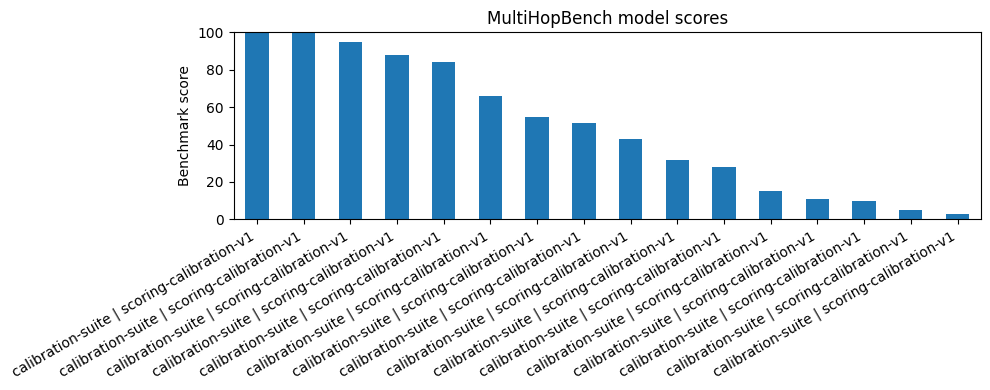

In [15]:
# Compact visual comparison. Official score is shown when available; otherwise provisional.
if not model_summary.empty:
    plot_df = model_summary.copy()
    plot_df["display_score"] = plot_df["official_benchmark_score"].fillna(plot_df["provisional_benchmark_score"])
    labels = plot_df["model_name"].astype(str)
    if len(plot_df) > 1:
        labels = labels + " | " + plot_df["setting"].astype(str)
    ax = plot_df.set_index(labels)["display_score"].plot(kind="bar", figsize=(10, 4), ylim=(0, 100))
    ax.set_ylabel("Benchmark score")
    ax.set_xlabel("")
    ax.set_title("MultiHopBench model scores")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 11. Output interpretation

- `final_score` is the score for an individual model–query pair.
- `provisional_benchmark_score` is the macro-average across all successfully scored queries for a model.
- `official_benchmark_score` is populated only when the full dataset is covered, there are no invalid annotations, and no rows require review, unless the strict policy is disabled.
- `coverage_rate` is the share of dataset queries present in the input file.
- `scored_coverage_rate` is the share of dataset queries that successfully reached the scoring stage.

Every query has equal weight. The scorer does not compute a micro-average over entities, so records with long gold lists do not dominate the aggregate result.
